In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from datetime import datetime
import numpy as np
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

# Getting the same results with train and train_manual_update
- Write torch.manual_seed(42) at the beginning of your notebook.
- Write torch.set_default_dtype(torch.double) at the beginning of your notebook to alleviate precision errors

In [2]:
SEED = 42

In [3]:
torch.manual_seed(SEED)
torch.set_default_dtype(torch.double)

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [5]:
save_dir = Path("imgs/gd")
save_dir.mkdir(parents=True, exist_ok=True)

# Tasks
Load, analyse and preprocess the CIFAR-10 dataset. Split it into 3
datasets: training, validation and test. Take a subset of these datasets
by keeping only 2 labels: cat and car

In [6]:
def show_img(img, label) -> None:
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

In [7]:
class CIFAR2(Dataset):
    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.data, self.targets = self.__loaddata__()

        self.transformer = transforms.Compose(
            [
                transforms.ToTensor(),
            ]
        )

    def set_transformer(self, transformer: transforms.Compose):
        self.transformer = transformer

    def __loaddata__(self):
        data = datasets.CIFAR10(root=str(self.data_path), transform=None, download=True)
        targets = np.array(data.targets)
        indices = (targets == 0) | (targets == 2)  # plane, bird

        images, targets = data.data[indices], targets[indices]

        # resample 0 is ok, 2 -> 1
        targets = [1 if t == 2 else t for t in targets]

        return images, targets

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        img, target = self.data[idx], self.targets[idx]
        return self.transformer(img), target

    def __len__(self):
        return len(self.data)

In [8]:
class Preprocessor:
    def __init__(self):
        self.transformer = None
        self.mean = None
        self.std = None

    def fit(self, train_loader):
        mean = 0.0
        std = 0.0
        total_images = 0

        for images, _ in train_loader:
            batch_samples = images.size(0)
            images = images.view(batch_samples, images.size(1), -1)
            mean += images.mean(2).sum(0)
            std += images.std(2).sum(0)
            total_images += batch_samples

        self.mean = mean / total_images
        self.std = std / total_images

        self.transformer = transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize(self.mean, self.std)]
        )
        return self.transformer

    def process(self, data):
        return self.transformer(data)

    def unnormalize(self, img):
        img = img.clone()
        for c in range(img.shape[0]):
            img[c] = img[c] * self.std[c] + self.mean[c]
        return torch.clamp(img, 0, 1)

In [9]:
def load_cifar(
    train_val_split=0.9, data_path="data/", preprocessor: Preprocessor = None
):
    cifar2 = CIFAR2(Path(data_path))

    train_size = int(len(cifar2) * train_val_split)
    val_test_size = len(cifar2) - train_size

    cifar_generator = torch.Generator().manual_seed(SEED)
    train, val_test = random_split(
        cifar2, lengths=[train_size, val_test_size], generator=cifar_generator
    )

    test_val_split = 0.5  # 0.05, 0.05
    val_size = int(len(val_test) * test_val_split)
    test_size = len(val_test) - val_size

    val, test = random_split(
        val_test, lengths=[val_size, test_size], generator=cifar_generator
    )

    batch_size = 32

    # get mean and std from train data only
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=False)
    train_transforms = preprocessor.fit(train_loader)
    cifar2.set_transformer(train_transforms)

    # now cifar2 loads and
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

Write a MyMLP class that implements a MLP in PyTorch (so only fully
connected layers) such that:
    
    - The input dimension is 768(= 16 ∗ 16 ∗ 3) and the output dimension is 2 (for the 2 classes).
    - The hidden layers have respectively 128 and 32 hidden units.
    - All activation functions are ReLU. The last layer has no activation function since the cross-entropy loss already includes a softmax activation
function.

In [10]:
class MyMLP(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 32 relu
    out layer: 32 - 2 no activation function
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)  # final layer
        # no softmax, we are using cross entropy loss
        return out

Write a train(n_epochs, optimizer, model, loss_fn, train_loader) function that trains model for n_epochs epochs given an optimizer optimizer, a loss function loss_fn and a dataloader train_loader.

In [11]:
def train(n_epochs, optimizer, model, loss_fn, train_loader):
    n_batch = len(train_loader)
    losses_train = []
    model.train()  # set to train mode
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device, dtype=torch.double)
            labels = labels.to(device=device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        losses_train.append(loss_train / n_batch)

        if epoch == 1 or epoch % 10 == 0:
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch
                )
            )
    return losses_train

In [12]:
net = MyMLP()
cifar = CIFAR2("data/")

/home/henrik/school/inf265_projects/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Write a similar function train manual_update that has no optimizer parameter, but a learning rate lr parameter instead and that manually updates each trainable parameter of model using equation (2). Do not forget to zero out all gradients after each iteration. 

Train 2 instances of MyMLP, one using train and the other using train_manual_update (use the same parameter values for both models). Compare their respective training losses. To get exactly the same results with both functions, see section 3.3

In [13]:
def train_manual_update(
    n_epochs, model, loss_fn, train_loader, lr, weight_decay, momentum
):
    n_batch = len(train_loader)
    model.train()
    losses_train = []

    velocities = [torch.zeros_like(p.data) for p in model.parameters()]

    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device, dtype=torch.double)
            labels = labels.to(device=device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            loss.backward()

            with torch.no_grad():
                for v, p in zip(velocities, model.parameters()):
                    if p.grad is not None:
                        grad = p.grad + weight_decay * p.data
                        v.mul_(momentum).add_(grad)
                        p.data -= lr * v

            model.zero_grad(set_to_none=False)

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch
                )
            )

        losses_train.append(loss_train / len(train_loader))
    return losses_train

In [14]:
processor = Preprocessor()
train_loader, val_loader, test_loader = load_cifar(preprocessor=processor)

In [15]:
loss_fn = nn.CrossEntropyLoss()

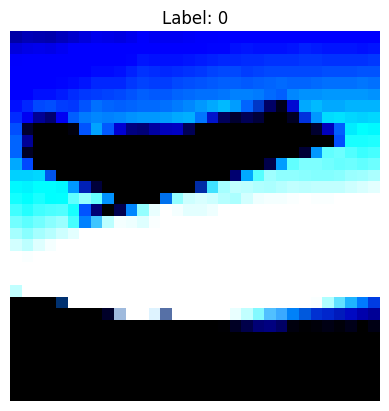

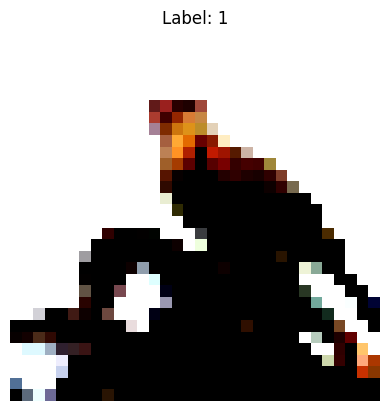

In [16]:
batch = next(iter(train_loader))
imgs, labels = batch
show_img(imgs[0], labels[0])  # plane = label 0
show_img(imgs[3], labels[3])  # bird = label 1

23:00:39.671872  |  Epoch 1  |  Training loss 0.527
23:00:56.996151  |  Epoch 10  |  Training loss 0.201
23:01:15.426846  |  Epoch 20  |  Training loss 0.076
23:01:18.974713  |  Epoch 1  |  Training loss 0.527
23:01:50.149800  |  Epoch 10  |  Training loss 0.201
23:02:25.655558  |  Epoch 20  |  Training loss 0.076


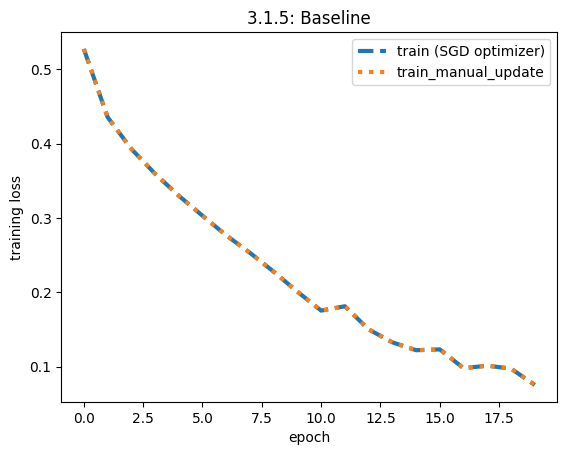

In [17]:
# 3.1.5

n_epochs = 20
lr = 1e-2

# instance 1: train
torch.manual_seed(SEED)
model_opt = MyMLP().to(device)
optimizer = torch.optim.SGD(
    model_opt.parameters(), lr=lr, momentum=0.0, weight_decay=0.0
)
losses_opt = train(n_epochs, optimizer, model_opt, loss_fn, train_loader)

# instance 2: train_manual_update
torch.manual_seed(SEED)
model_man = MyMLP().to(device)
losses_man = train_manual_update(
    n_epochs, model_man, loss_fn, train_loader, lr=lr, weight_decay=0.0, momentum=0.0
)

plt.plot(losses_opt, label="train (SGD optimizer)", linestyle = "dashed", linewidth = "3")
plt.plot(losses_man, label="train_manual_update", linestyle = "dotted", linewidth = "3")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("3.1.5: Baseline")
plt.savefig(save_dir / "3_1_5.png")
plt.show()

23:02:28.179553  |  Epoch 1  |  Training loss 0.527
23:02:49.262592  |  Epoch 10  |  Training loss 0.204
23:03:12.663644  |  Epoch 20  |  Training loss 0.078
23:03:16.299245  |  Epoch 1  |  Training loss 0.527
23:03:47.388447  |  Epoch 10  |  Training loss 0.204
23:04:21.830653  |  Epoch 20  |  Training loss 0.073


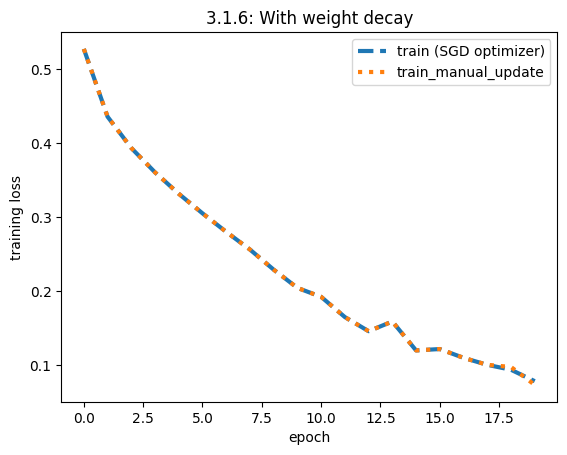

In [18]:
# 3.1.6

n_epochs = 20
lr = 1e-2

wd = 1e-3

# instance 1: train
torch.manual_seed(SEED)
model_opt = MyMLP().to(device)
optimizer = torch.optim.SGD(
    model_opt.parameters(), lr=lr, momentum=0.0, weight_decay=wd
)
losses_opt = train(n_epochs, optimizer, model_opt, loss_fn, train_loader)

# instance 2: train_manual_update
torch.manual_seed(SEED)
model_man = MyMLP().to(device)
losses_man = losses_man = train_manual_update(
    n_epochs, model_man, loss_fn, train_loader, lr=lr, weight_decay=wd, momentum=0.0
)

plt.plot(losses_opt, label="train (SGD optimizer)", linestyle = "dashed", linewidth = "3")
plt.plot(losses_man, label="train_manual_update", linestyle = "dotted", linewidth = "3")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("3.1.6: With weight decay")
plt.savefig(save_dir / "3_1_6.png")
plt.show()

23:04:24.600896  |  Epoch 1  |  Training loss 0.476
23:04:48.047076  |  Epoch 10  |  Training loss 0.193
23:05:13.788730  |  Epoch 20  |  Training loss 0.109
23:05:17.267838  |  Epoch 1  |  Training loss 0.476
23:05:48.417417  |  Epoch 10  |  Training loss 0.193
23:06:22.701264  |  Epoch 20  |  Training loss 0.105


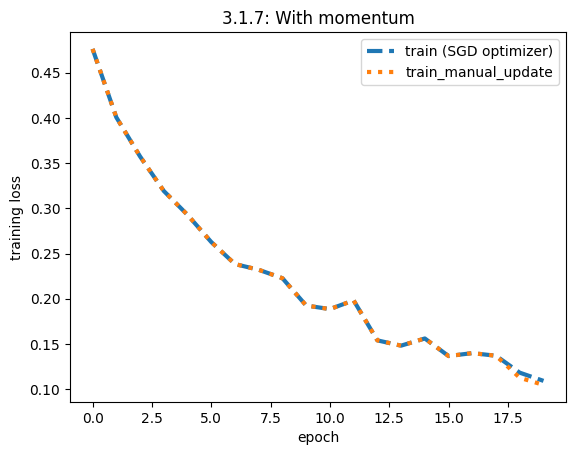

In [19]:
# 3.1.7

n_epochs = 20
lr = 1e-2

wd = 1e-3

momentum = 0.9

# instance 1: train
torch.manual_seed(SEED)
model_opt = MyMLP().to(device)
optimizer = torch.optim.SGD(
    model_opt.parameters(), lr=lr, momentum=momentum, weight_decay=wd
)
losses_opt = train(n_epochs, optimizer, model_opt, loss_fn, train_loader)

# instance 2: train_manual_update
torch.manual_seed(SEED)
model_man = MyMLP().to(device)
losses_man = losses_man = train_manual_update(
    n_epochs,
    model_man,
    loss_fn,
    train_loader,
    lr=lr,
    weight_decay=wd,
    momentum=momentum,
)

plt.plot(losses_opt, label="train (SGD optimizer)", linestyle = "dashed", linewidth = "3")
plt.plot(losses_man, label="train_manual_update", linestyle = "dotted", linewidth = "3")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("3.1.7: With momentum")
plt.savefig(save_dir / "3_1_7.png")
plt.show()